In [9]:
!pip install --upgrade tensorflow imbalanced-learn scikit-learn shap "protobuf>=6.31.1" -q

In [1]:
# ============================================================
# BLOCK 1 — SETUP (LSTM)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("GPU available:", tf.config.list_physical_devices('GPU'))
if not tf.config.list_physical_devices('GPU'):
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > T4 GPU before continuing.")

# from google.colab import drive
# drive.mount('/content/drive')

X_SEQ_PATH = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/X_seq.npy"
Y_SEQ_PATH = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/y_seq.npy"
META_PATH  = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/seq_meta.csv"

X_seq = np.load(X_SEQ_PATH)
y_seq = np.load(Y_SEQ_PATH)
seq_meta = pd.read_csv(META_PATH)

print("X_seq shape:", X_seq.shape, " (n_sequences, seq_len, n_features)")
print("y_seq shape:", y_seq.shape)
print("y_seq unique values:", np.unique(y_seq))
print("\nseq_meta shape:", seq_meta.shape)
print("seq_meta columns:", list(seq_meta.columns))
print(seq_meta.head())

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
X_seq shape: (918847, 20, 18)  (n_sequences, seq_len, n_features)
y_seq shape: (918847,)
y_seq unique values: [0 1 3]

seq_meta shape: (918847, 3)
seq_meta columns: ['trading_code', 'date', 'split']
  trading_code        date  split
0     AAMRANET  2017-11-23  train
1     AAMRANET  2017-11-26  train
2     AAMRANET  2017-11-27  train
3     AAMRANET  2017-11-28  train
4     AAMRANET  2017-11-29  train


In [2]:
# ============================================================
# BLOCK 2 — FEATURES / TARGET / TRAIN-TEST SPLIT (sequence-aligned)
# ASSUMPTION (confirm against Block 1 output): seq_meta has columns
# ['trading_code','date','split','target_class'], row-aligned 1:1 with
# X_seq/y_seq (row i of seq_meta corresponds to X_seq[i], y_seq[i]).
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]
assert X_seq.shape[-1] == len(ALL_FEATURES), \
    f"X_seq has {X_seq.shape[-1]} features, expected {len(ALL_FEATURES)} — check feature order/list."
assert len(seq_meta) == len(X_seq) == len(y_seq), "seq_meta / X_seq / y_seq row counts don't match."

LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}
CRASH_IDX   = 2

# Remap y_seq to {0,1,2} only if it's still in original {0,1,3} form
if set(np.unique(y_seq)) <= {0, 1, 3}:
    y_seq_mapped = np.vectorize(LABEL_MAP.get)(y_seq)
else:
    y_seq_mapped = y_seq.copy()
assert set(np.unique(y_seq_mapped)) <= {0, 1, 2}, "Unexpected label values after remapping."

seq_meta["y"] = y_seq_mapped

train_mask = (seq_meta["split"] == "train").values
test_mask  = (seq_meta["split"] == "test").values

X_train_seq, y_train_seq = X_seq[train_mask], y_seq_mapped[train_mask]
X_test_seq,  y_test_seq  = X_seq[test_mask],  y_seq_mapped[test_mask]

train_meta = seq_meta[train_mask].reset_index(drop=True)
test_meta  = seq_meta[test_mask].reset_index(drop=True)

print("Train sequences:", X_train_seq.shape, " Test sequences:", X_test_seq.shape)
print("Train class balance:", np.round(np.bincount(y_train_seq) / len(y_train_seq), 4))
print("Test  class balance:", np.round(np.bincount(y_test_seq) / len(y_test_seq), 4))

Train sequences: (624454, 20, 18)  Test sequences: (294393, 20, 18)
Train class balance: [0.7403 0.2046 0.0552]
Test  class balance: [0.7379 0.215  0.0471]


In [3]:
# ============================================================
# BLOCK 4 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO (sequences)
# Same logic as the tabular models, applied to sequence target dates.
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

train_meta["date"] = pd.to_datetime(train_meta["date"])
unique_train_dates = np.sort(train_meta["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_meta["date"].values
cv_splits_seq = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits_seq.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} seqs) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} seqs)")

Fold 1: train 2008-05-04->2010-02-02 (80,616 seqs) | val 2010-02-10->2011-11-28 (89,975 seqs)
Fold 2: train 2008-05-04->2011-11-21 (170,519 seqs) | val 2011-11-29->2013-09-16 (96,727 seqs)
Fold 3: train 2008-05-04->2013-09-09 (267,141 seqs) | val 2013-09-17->2015-06-28 (108,131 seqs)
Fold 4: train 2008-05-04->2015-06-21 (375,098 seqs) | val 2015-06-29->2017-03-28 (120,340 seqs)
Fold 5: train 2008-05-04->2017-03-20 (495,362 seqs) | val 2017-03-29->2018-12-23 (126,717 seqs)


In [4]:
# ============================================================
# BLOCK 5-LSTM — SCORER + MODEL ARCHITECTURE BUILDER
# ============================================================
def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

def build_lstm(input_shape, units1=64, units2=32, dropout=0.3, lr=1e-3):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(units2),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(3, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def get_class_weight_dict(y):
    classes = np.unique(y)
    weights = compute_class_weight("balanced", classes=classes, y=y)
    return dict(zip(classes, weights))

print("Scorers and model builder ready.")

Scorers and model builder ready.


In [5]:
# ============================================================
# BLOCK 6-LSTM — SCORERS
# crash_pr_auc / macro_pr_auc are already used as plain Python functions
# throughout Blocks 7-16 (since Keras training doesn't go through sklearn's
# GridSearchCV/RandomizedSearchCV the way the tree models did). This block
# additionally wraps them as sklearn make_scorer objects for consistency
# with the other model notebooks, and in case a later stage (e.g. the
# stacking ensemble) needs a proper scorer object rather than a raw function.
# ============================================================
from sklearn.metrics import make_scorer

def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

crash_scorer = make_scorer(crash_pr_auc, response_method="predict_proba")

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

macro_scorer = make_scorer(macro_pr_auc, response_method="predict_proba")

print("Scorers ready: crash_pr_auc / macro_pr_auc (plain functions, used directly in Blocks 7-16),")
print("crash_scorer / macro_scorer (make_scorer objects, kept for consistency / later reuse).")

Scorers ready: crash_pr_auc / macro_pr_auc (plain functions, used directly in Blocks 7-16),
crash_scorer / macro_scorer (make_scorer objects, kept for consistency / later reuse).


In [6]:
# ============================================================
# BLOCK 7-LSTM — HYPERPARAMETER SEARCH (single validation fold, 4 candidates)
# Full 5-fold search is infeasible for deep learning at this scale within
# available time; single-split tuning + full-CV final evaluation is the
# standard compute-bounded approach for neural architectures (Reviewer 3
# "broaden or justify via compute constraints").
# ============================================================
tr_idx_search, va_idx_search = cv_splits_seq[-1]   # last (largest) fold for tuning
X_tr_s, y_tr_s = X_train_seq[tr_idx_search], y_train_seq[tr_idx_search]
X_va_s, y_va_s = X_train_seq[va_idx_search], y_train_seq[va_idx_search]
cw = get_class_weight_dict(y_tr_s)

CANDIDATES = [
    {"units1": 64, "units2": 32, "dropout": 0.2, "lr": 1e-3, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.3, "lr": 5e-4, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.4, "lr": 5e-4, "batch_size": 256},
]

results_lstm = []
for i, cand in enumerate(CANDIDATES):
    print(f"\n--- Candidate {i+1}/{len(CANDIDATES)}: {cand} ---")
    t0 = time.time()
    model = build_lstm(input_shape=(X_tr_s.shape[1], X_tr_s.shape[2]),
                        units1=cand["units1"], units2=cand["units2"],
                        dropout=cand["dropout"], lr=cand["lr"])
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
              epochs=20, batch_size=cand["batch_size"], class_weight=cw,
              callbacks=[es], verbose=0)
    proba = model.predict(X_va_s, verbose=0)
    score = crash_pr_auc(y_va_s, proba)
    elapsed = time.time() - t0
    print(f"  crash_PR-AUC={score:.4f}  ({elapsed:.0f}s)")
    results_lstm.append({**cand, "crash_pr_auc": score, "time_s": elapsed})

results_df = pd.DataFrame(results_lstm).sort_values("crash_pr_auc", ascending=False)
print("\n=== CANDIDATE RESULTS ===")
print(results_df)

best_params_lstm = results_df.iloc[0][["units1","units2","dropout","lr","batch_size"]].to_dict()
best_params_lstm["units1"] = int(best_params_lstm["units1"])
best_params_lstm["units2"] = int(best_params_lstm["units2"])
best_params_lstm["batch_size"] = int(best_params_lstm["batch_size"])
print("\n=== BEST PARAMS ===")
print(best_params_lstm)


--- Candidate 1/4: {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 256} ---
  crash_PR-AUC=0.1528  (252s)

--- Candidate 2/4: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 256} ---
  crash_PR-AUC=0.1434  (107s)

--- Candidate 3/4: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 256} ---
  crash_PR-AUC=0.1211  (107s)

--- Candidate 4/4: {'units1': 64, 'units2': 32, 'dropout': 0.4, 'lr': 0.0005, 'batch_size': 256} ---
  crash_PR-AUC=0.1148  (124s)

=== CANDIDATE RESULTS ===
   units1  units2  dropout      lr  batch_size  crash_pr_auc      time_s
0      64      32      0.2  0.0010         256      0.152752  251.993445
1      64      32      0.3  0.0010         256      0.143428  106.841843
2      64      32      0.3  0.0005         256      0.121145  106.787557
3      64      32      0.4  0.0005         256      0.114784  123.638106

=== BEST PARAMS ===
{'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001, 'ba

In [8]:
# ============================================================
# BLOCK 8-LSTM (fixed) — CV FOLD-LEVEL METRICS WITH FINAL ARCHITECTURE
# ============================================================
model_build_params = {k: v for k, v in best_params_lstm.items() if k != "batch_size"}
batch_size_final = best_params_lstm["batch_size"]

fold_metrics_lstm = []
for i, (tr_idx, va_idx) in enumerate(cv_splits_seq):
    X_tr, y_tr = X_train_seq[tr_idx], y_train_seq[tr_idx]
    X_va, y_va = X_train_seq[va_idx], y_train_seq[va_idx]
    cw_fold = get_class_weight_dict(y_tr)

    model = build_lstm(input_shape=(X_tr.shape[1], X_tr.shape[2]), **model_build_params)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=20, batch_size=batch_size_final, class_weight=cw_fold,
              callbacks=[es], verbose=0)

    proba = model.predict(X_va, verbose=0)
    pred = proba.argmax(axis=1)

    fold_metrics_lstm.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc(y_va, proba),
        "macro_pr_auc": macro_pr_auc(y_va, proba),
        "crash_recall": recall_score(y_va == CRASH_IDX, pred == CRASH_IDX),
        "crash_precision": precision_score(y_va == CRASH_IDX, pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va, proba, multi_class="ovr"),
    })
    print(f"Fold {i+1} done — crash_PR-AUC={fold_metrics_lstm[-1]['crash_pr_auc']:.4f}")

fold_df_lstm = pd.DataFrame(fold_metrics_lstm).set_index("fold")
print(fold_df_lstm.round(4))
print("\nMean ± Std across folds:")
print((fold_df_lstm.mean().round(4).astype(str) + " ± " + fold_df_lstm.std().round(4).astype(str)))

Fold 1 done — crash_PR-AUC=0.1538
Fold 2 done — crash_PR-AUC=0.1142
Fold 3 done — crash_PR-AUC=0.1443
Fold 4 done — crash_PR-AUC=0.1373
Fold 5 done — crash_PR-AUC=0.1539
      crash_pr_auc  macro_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                                        
1           0.1538        0.4550        0.2489           0.1763       0.6816
2           0.1142        0.4571        0.1313           0.1084       0.6933
3           0.1443        0.4749        0.1647           0.1784       0.7428
4           0.1373        0.4738        0.1944           0.1577       0.7769
5           0.1539        0.4749        0.2487           0.1546       0.7664

Mean ± Std across folds:
crash_pr_auc       0.1407 ± 0.0164
macro_pr_auc       0.4671 ± 0.0102
crash_recall       0.1976 ± 0.0518
crash_precision    0.1551 ± 0.0282
roc_auc_ovr        0.7322 ± 0.0429
dtype: object


Epoch 1/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.5634 - loss: 0.9986
Epoch 2/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5835 - loss: 0.9671
Epoch 3/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5875 - loss: 0.9589
Epoch 4/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5904 - loss: 0.9530
Epoch 5/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5952 - loss: 0.9490
Epoch 6/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.5975 - loss: 0.9459
Epoch 7/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.5999 - loss: 0.9439
Epoch 8/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.6001 - loss: 0.9415
Epoch 9/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6017 - loss: 0.9401
Epoch 10/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6034 - loss: 0.9378
Epoch 11/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6060 - loss: 0.9359
Epoch 12/25
2440/24

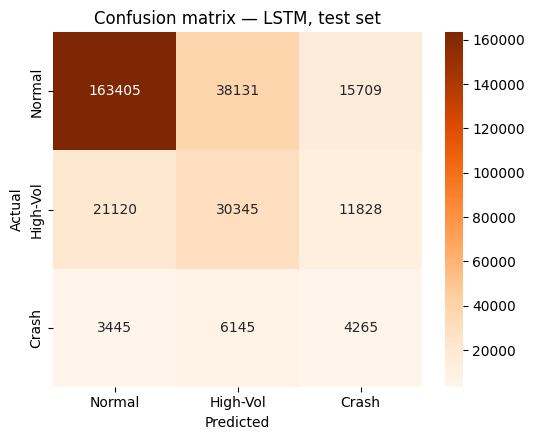


Crash-class PR-AUC : 0.1361
Macro PR-AUC       : 0.4898
ROC-AUC (OvR)      : 0.7690


In [11]:
# ============================================================
# BLOCK 9-LSTM — FINAL MODEL: fit on full train, evaluate on held-out test
# ============================================================
cw_full = get_class_weight_dict(y_train_seq)

# split out batch_size (a .fit()-time param) from the architecture kwargs (build_lstm-time params)
model_params_lstm = {k: v for k, v in best_params_lstm.items() if k != "batch_size"}
batch_size_lstm = best_params_lstm.get("batch_size", 32)  # fallback if somehow missing

final_model_lstm = build_lstm(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), **model_params_lstm)
es = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
history = final_model_lstm.fit(X_train_seq, y_train_seq, epochs=25,
                                batch_size=batch_size_lstm,
                                class_weight=cw_full, callbacks=[es], verbose=1)

test_proba_lstm = final_model_lstm.predict(X_test_seq, verbose=0)
test_pred_lstm  = test_proba_lstm.argmax(axis=1)

print("=== Classification report (test set) — LSTM ===")
print(classification_report(y_test_seq, test_pred_lstm, target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_lstm = confusion_matrix(y_test_seq, test_pred_lstm)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — LSTM, test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc(y_test_seq, test_proba_lstm):.4f}")
print(f"Macro PR-AUC       : {macro_pr_auc(y_test_seq, test_proba_lstm):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test_seq, test_proba_lstm, multi_class='ovr'):.4f}")

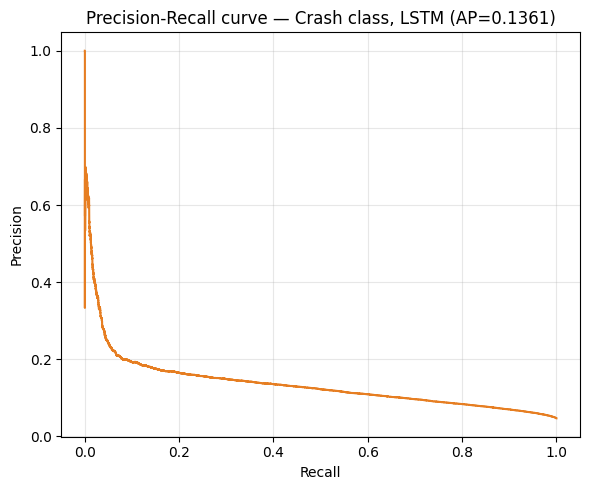

Recall @ FPR<=5%: 0.2003  (threshold=0.4877)
Precision@top-50 alerts: 0.6400
Precision@top-100 alerts: 0.6400
Precision@top-500 alerts: 0.4460
Precision@top-1000 alerts: 0.3640

Event-level crash recall (±1 day tolerance): 0.4890  (11451 distinct crash episodes)


In [12]:
# ============================================================
# BLOCK 10-LSTM — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec_l, rec_l, _ = precision_recall_curve(y_test_seq == CRASH_IDX, test_proba_lstm[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_l, prec_l, color="#e67e22")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, LSTM "
          f"(AP={average_precision_score(y_test_seq==CRASH_IDX, test_proba_lstm[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_l, tpr_l, roc_thresh_l = roc_curve(y_test_seq == CRASH_IDX, test_proba_lstm[:, CRASH_IDX])
target_fpr = 0.05
idx = max(np.searchsorted(fpr_l, target_fpr, side="right") - 1, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_l[idx]:.4f}  (threshold={roc_thresh_l[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_lstm[:, CRASH_IDX])[:k]
    prec_at_k = (y_test_seq[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

# Event-level detection, adapted for sequence meta (trading_code/date come from test_meta)
def event_level_recall_seq(meta_df, y_true, y_pred, tolerance=1):
    tdf = meta_df.copy()
    tdf["y_true"] = y_true
    tdf["y_pred"] = y_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall_lstm, n_events_lstm = event_level_recall_seq(test_meta, y_test_seq, test_pred_lstm, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_lstm:.4f}  ({n_events_lstm} distinct crash episodes)")

Brier score (crash)                       : 0.08238
Brier score, prevalence-only baseline     : 0.04485
Brier Skill Score vs. prevalence baseline : -0.8369


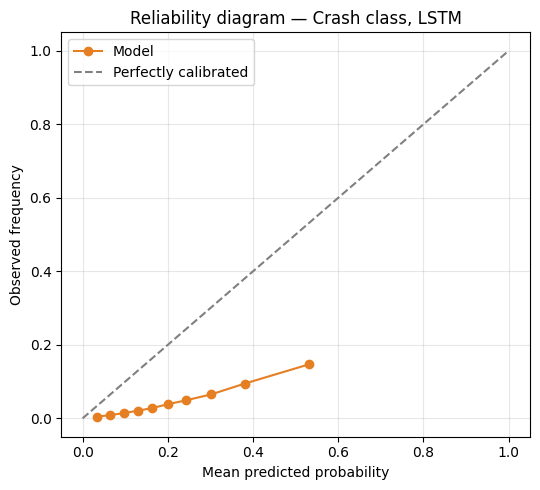


Expected Calibration Error (crash): 0.1674


In [13]:
# ============================================================
# BLOCK 11-LSTM — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test_seq == CRASH_IDX).astype(int)
p_crash_lstm = test_proba_lstm[:, CRASH_IDX]

brier_lstm = brier_score_loss(y_crash_true, p_crash_lstm)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_lstm, prevalence))
brier_skill_score_lstm = 1 - (brier_lstm / brier_baseline)

print(f"Brier score (crash)                       : {brier_lstm:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_lstm:.4f}")

frac_pos_l, mean_pred_l = calibration_curve(y_crash_true, p_crash_lstm, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_l, frac_pos_l, marker="o", color="#e67e22", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, LSTM")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_crash_lstm, bins) - 1
ece_lstm = 0.0
for b in range(10):
    mask = bin_ids == b
    if mask.sum() == 0: continue
    ece_lstm += (mask.sum() / len(p_crash_lstm)) * abs(y_crash_true[mask].mean() - p_crash_lstm[mask].mean())
print(f"\nExpected Calibration Error (crash): {ece_lstm:.4f}")

In [14]:
# ============================================================
# BLOCK 12-LSTM — REGIME-SPECIFIC PERFORMANCE
# ============================================================
REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_meta_eval = test_meta.copy()
test_meta_eval["date"] = pd.to_datetime(test_meta_eval["date"])
test_meta_eval["y_true"] = y_test_seq
test_meta_eval["y_pred"] = test_pred_lstm
test_meta_eval["p_crash"] = test_proba_lstm[:, CRASH_IDX]

regime_rows_lstm = []
for name, (start, end) in REGIMES.items():
    mask = (test_meta_eval["date"] >= start) & (test_meta_eval["date"] <= end)
    sub = test_meta_eval[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_lstm.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_lstm = pd.DataFrame(regime_rows_lstm).set_index("regime")
print(regime_df_lstm.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88045      0.0521        0.2892           0.1517   
COVID crash              6099      0.2289        0.2822           0.2199   
Post-COVID recovery    123425      0.0472        0.3285           0.1241   
Russia-Ukraine (2022)   64780      0.0262        0.3168           0.1046   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1499  
COVID crash                  0.2594  
Post-COVID recovery          0.1266  
Russia-Ukraine (2022)        0.1071  


In [15]:
# ============================================================
# BLOCK 13-LSTM — CUSTOM PERMUTATION IMPORTANCE (sequence-aware)
# ============================================================
LABEL_ADJACENT = ["daily_return", "intraday_volatility"]

def permutation_importance_seq(model, X, y_true, feature_names, n_repeats=3, random_state=42):
    rng = np.random.RandomState(random_state)
    baseline_proba = model.predict(X, verbose=0)
    baseline_score = crash_pr_auc(y_true, baseline_proba)

    results = []
    for f_idx, fname in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            # shuffle this feature across the sample axis, keeping timestep structure
            perm_order = rng.permutation(X_perm.shape[0])
            X_perm[:, :, f_idx] = X_perm[perm_order, :, f_idx]
            proba_perm = model.predict(X_perm, verbose=0)
            drops.append(baseline_score - crash_pr_auc(y_true, proba_perm))
        results.append({"feature": fname, "importance_mean": np.mean(drops), "importance_std": np.std(drops)})
    return pd.DataFrame(results)

# Subsample test set for speed (permutation importance requires many forward passes)
subsample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_seq), min(10000, len(X_test_seq)), replace=False)
X_test_sub = X_test_seq[subsample_idx]
y_test_sub = y_test_seq[subsample_idx]

perm_df_lstm = permutation_importance_seq(final_model_lstm, X_test_sub, y_test_sub, ALL_FEATURES, n_repeats=3)
perm_df_lstm["label_adjacent"] = perm_df_lstm["feature"].isin(LABEL_ADJACENT)
perm_df_lstm = perm_df_lstm.sort_values("importance_mean", ascending=False)

print("="*70)
print("PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test subsample) — LSTM")
print("="*70)
print(perm_df_lstm.round(5))
print("\n(Interpret as associational, not causal — Reviewer 4.)")

PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test subsample) — LSTM
                  feature  importance_mean  importance_std  label_adjacent
12                stoch_k          0.04654         0.00390           False
2     intraday_volatility          0.03929         0.00430            True
13                stoch_d          0.02729         0.00163           False
3       volume_change_pct          0.00818         0.00142           False
0            daily_return          0.00498         0.00255            True
5   rolling_5d_volatility          0.00420         0.00034           False
14                 roc_10          0.00408         0.00110           False
7                  ema_12          0.00372         0.00175           False
1         high_low_spread          0.00301         0.00165           False
9             macd_signal          0.00223         0.00099           False
17                    obv          0.00143         0.00016           False
10              macd_hist   

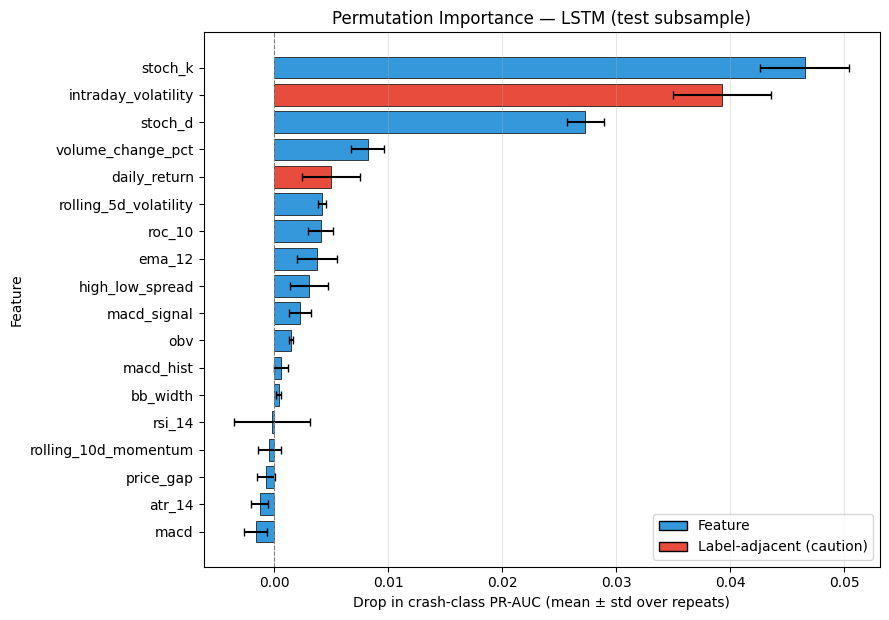

In [16]:
# ============================================================
# BLOCK 13-LSTM (continued) — PLOT: Permutation Importance
# ============================================================
plt.figure(figsize=(9, max(4, 0.35 * len(perm_df_lstm))))

plot_df = perm_df_lstm.sort_values("importance_mean", ascending=True)
colors = ["#e74c3c" if adj else "#3498db" for adj in plot_df["label_adjacent"]]

plt.barh(plot_df["feature"], plot_df["importance_mean"],
         xerr=plot_df["importance_std"], color=colors,
         edgecolor="black", linewidth=0.5, capsize=3)

plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Drop in crash-class PR-AUC (mean ± std over repeats)")
plt.ylabel("Feature")
plt.title("Permutation Importance — LSTM (test subsample)")

# custom legend for label-adjacent highlighting
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#3498db", edgecolor="black", label="Feature"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Label-adjacent (caution)")
]
plt.legend(handles=legend_elems, loc="lower right")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# BLOCK 14-LSTM — SMOTE VARIANT (flatten sequences, SMOTE, reshape back)
# SMOTE only operates on 2D tabular data, so sequences are flattened to
# (n_samples, seq_len*n_features), resampled, then reshaped back — a
# standard workaround for applying SMOTE to sequence models.
# ============================================================
n_samples, seq_len, n_feat = X_train_seq.shape
X_train_flat = X_train_seq.reshape(n_samples, seq_len * n_feat)

X_res_flat, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_flat, y_train_seq)
X_res_seq = X_res_flat.reshape(-1, seq_len, n_feat)

print(f"Original class counts: {np.bincount(y_train_seq)}")
print(f"SMOTE-resampled class counts: {np.bincount(y_res)}")

# split out batch_size (a .fit()-time param) from the architecture kwargs (build_lstm-time params)
model_params_lstm = {k: v for k, v in best_params_lstm.items() if k != "batch_size"}
batch_size_lstm = best_params_lstm.get("batch_size", 32)

model_smote_lstm = build_lstm(input_shape=(seq_len, n_feat), **model_params_lstm)
es = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
model_smote_lstm.fit(X_res_seq, y_res, epochs=20, batch_size=batch_size_lstm,
                      callbacks=[es], verbose=1)

smote_test_proba_lstm = model_smote_lstm.predict(X_test_seq, verbose=0)
print(f"\n[SMOTE variant]        crash PR-AUC (test): {crash_pr_auc(y_test_seq, smote_test_proba_lstm):.4f}")
print(f"[Class-weight variant] crash PR-AUC (test): {crash_pr_auc(y_test_seq, test_proba_lstm):.4f}")

Original class counts: [462265 127738  34451]
SMOTE-resampled class counts: [462265 462265 462265]
Epoch 1/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.5788 - loss: 0.8481
Epoch 2/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.6181 - loss: 0.7851
Epoch 3/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.6320 - loss: 0.7620
Epoch 4/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6409 - loss: 0.7464
Epoch 5/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6472 - loss: 0.7357
Epoch 6/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6524 - loss: 0.7266
Epoch 7/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6560 - loss: 0.7198
Epoch 8/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6604 - loss: 0.7126
Epoch 9/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6633 - loss: 0.7061
Epoch 10/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6662 - loss: 0.7020
Epoch 11/2

In [18]:
# ============================================================
# BLOCK 15-LSTM — SUMMARY TABLE
# ============================================================
summary_lstm = pd.DataFrame({
    "Model": ["LSTM (class-weighted)", "LSTM (SMOTE)"],
    "Crash PR-AUC": [
        crash_pr_auc(y_test_seq, test_proba_lstm),
        crash_pr_auc(y_test_seq, smote_test_proba_lstm),
    ],
    "Crash Recall": [
        recall_score(y_test_seq==CRASH_IDX, test_pred_lstm==CRASH_IDX),
        recall_score(y_test_seq==CRASH_IDX, smote_test_proba_lstm.argmax(axis=1)==CRASH_IDX),
    ],
})
print(summary_lstm.round(4))

                   Model  Crash PR-AUC  Crash Recall
0  LSTM (class-weighted)        0.1361        0.3078
1           LSTM (SMOTE)        0.1163        0.1013


1. CLASSIFICATION REPORT (test set) — LSTM
              precision  recall  f1-score      support
Normal           0.8693  0.7522    0.8065  217245.0000
High-Vol         0.4067  0.4794    0.4401   63293.0000
Crash            0.1341  0.3078    0.1868   13855.0000
accuracy         0.6726  0.6726    0.6726       0.6726
macro avg        0.4700  0.5131    0.4778  294393.0000
weighted avg     0.7352  0.6726    0.6986  294393.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds) — LSTM
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.1486         0.0298       0.2222      0.0705   
High-Vol              0.3931         0.0220       0.3911      0.0293   
Normal                0.8366         0.0521       0.8013      0.0717   
accuracy              0.6914         0.0874       0.6914      0.0874   
macro avg          

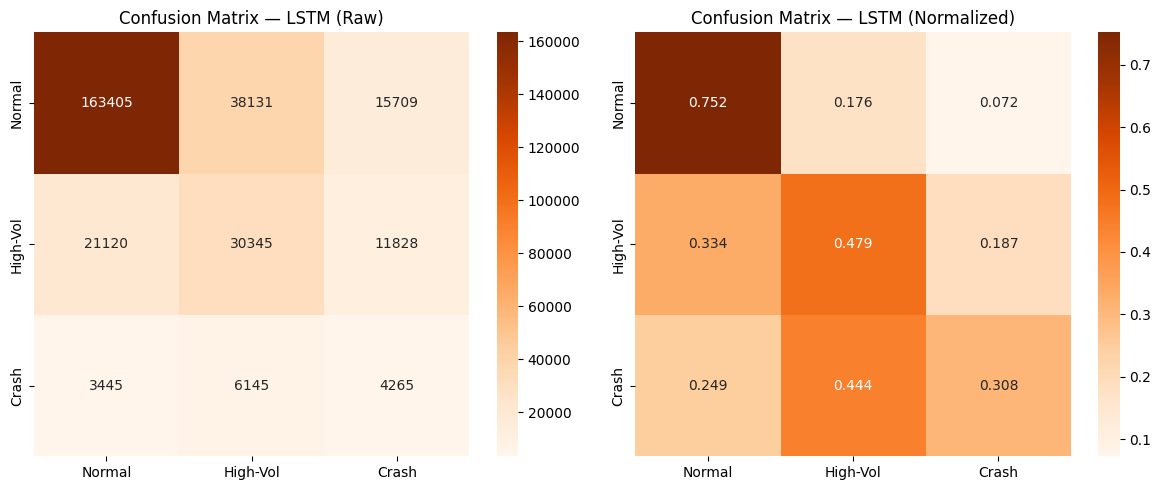

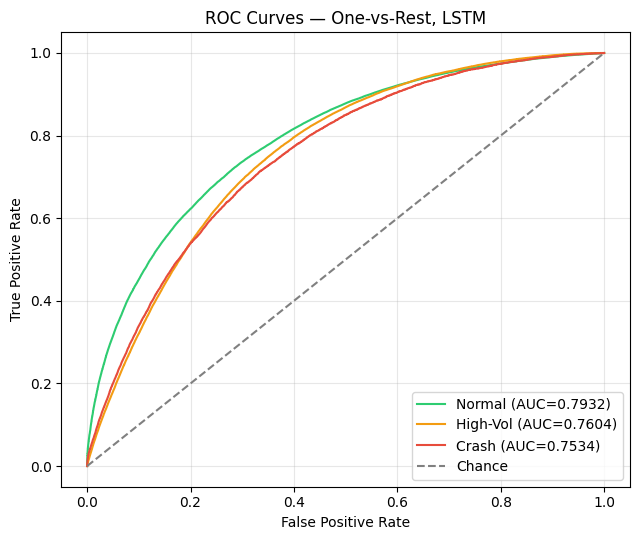


REPORT COMPLETE — LSTM


In [19]:
# ============================================================
# BLOCK 16-LSTM — FINAL COMPREHENSIVE REPORT
# ============================================================
CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

# split out batch_size (a .fit()-time param) from the architecture kwargs (build_lstm-time params)
model_params_lstm = {k: v for k, v in best_params_lstm.items() if k != "batch_size"}
batch_size_lstm = best_params_lstm.get("batch_size", 32)

print("="*70)
print("1. CLASSIFICATION REPORT (test set) — LSTM")
print("="*70)
report_dict_lstm = classification_report(y_test_seq, test_pred_lstm, target_names=CLASS_LABELS_LIST,
                                          digits=4, output_dict=True)
print(pd.DataFrame(report_dict_lstm).T.round(4))

print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds) — LSTM")
print("="*70)
per_fold_reports_lstm = []
for i, (tr_idx, va_idx) in enumerate(cv_splits_seq):
    X_tr, y_tr = X_train_seq[tr_idx], y_train_seq[tr_idx]
    X_va, y_va = X_train_seq[va_idx], y_train_seq[va_idx]
    cw_fold = get_class_weight_dict(y_tr)
    model = build_lstm(input_shape=(X_tr.shape[1], X_tr.shape[2]), **model_params_lstm)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=20,
              batch_size=batch_size_lstm, class_weight=cw_fold,
              callbacks=[es], verbose=0)
    va_pred = model.predict(X_va, verbose=0).argmax(axis=1)
    rep = classification_report(y_va, va_pred, target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = i + 1
    per_fold_reports_lstm.append(rep_df)
    print(f"Fold {i+1} done")

all_folds_df_lstm = pd.concat(per_fold_reports_lstm).reset_index().rename(columns={"index": "class_metric"})
cv_summary_lstm = all_folds_df_lstm.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary_lstm.columns = ["_".join(c) for c in cv_summary_lstm.columns]
print(cv_summary_lstm.round(4))

cm_raw_lstm = confusion_matrix(y_test_seq, test_pred_lstm)
cm_norm_lstm = confusion_matrix(y_test_seq, test_pred_lstm, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix — LSTM (Raw)")
sns.heatmap(cm_norm_lstm, annot=True, fmt=".3f", cmap="Oranges",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix — LSTM (Normalized)")
plt.tight_layout(); plt.show()

y_test_bin = label_binarize(y_test_seq, classes=CLASS_ORDER)
plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba_lstm[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, LSTM")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE — LSTM")
print("="*70)